<a href="https://colab.research.google.com/github/TheRealOP/Homework-Robot-Vis/blob/main/3_image_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 3
1. Upload a personal image in hosting place that can be accesed using an URL.
2. Perform filtering using a 3x3 and then a 5x5 box filter. Show the resulting images. What is the effect of applying a box filter. Explain the differences between the two resulting images.


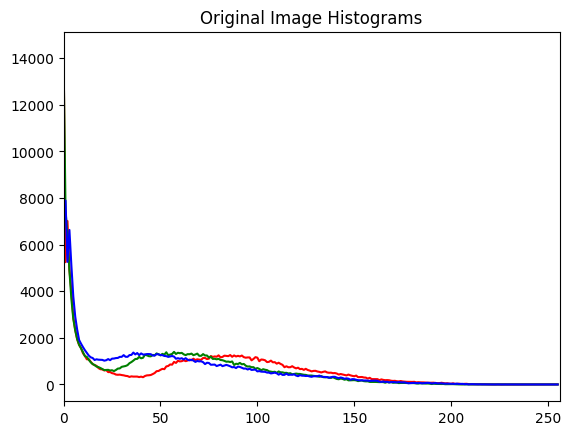

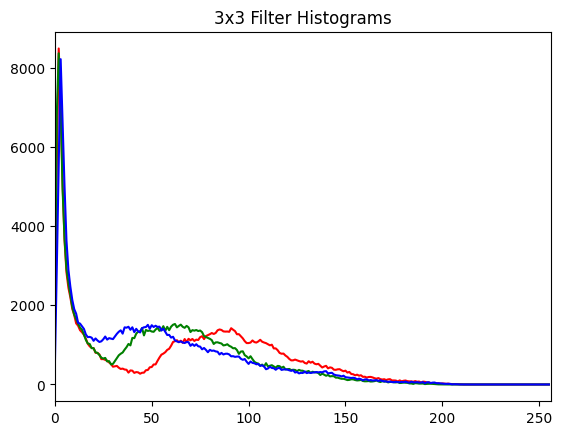

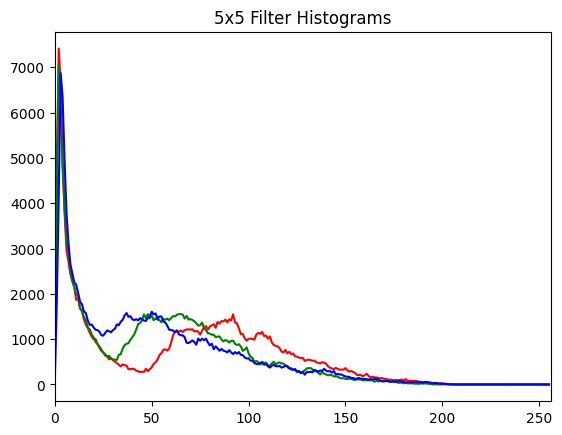

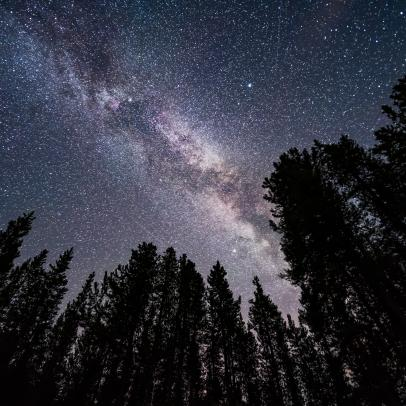

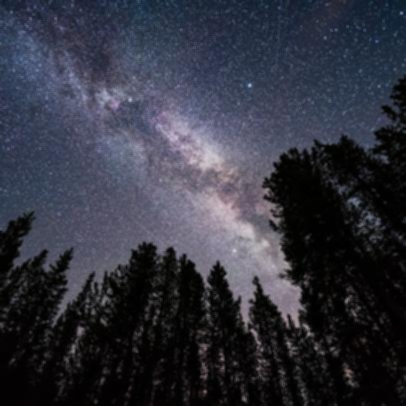

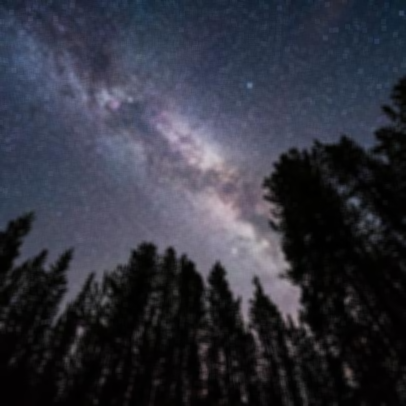

In [36]:
from skimage import io
import cv2
from google.colab.patches import cv2_imshow # for image display
import matplotlib.pyplot as plt



yourUrl = 'https://discovery.sndimg.com/content/dam/images/discovery/editorial/podcasts/Curiosity/2020/3/GettyImages-1134062152.jpg.rend.hgtvcom.406.406.suffix/1583191585259.jpeg'
response = requests.get(yourUrl, headers={"User-Agent": "Mozilla/5.0"})
image_data = BytesIO(response.content)
image = io.imread(yourUrl)

# convert to BGR if you are using openCV
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#prepare the 3x3 shaped filter
k1 = np.array([[1, 1, 1],
               [1, 1, 1],
               [1, 1, 1]], dtype=np.float32)
#prepare the 5x5 shaped filter
k2 = np.array([[1, 1, 1, 1, 1],
               [1, 1, 1, 1, 1],
               [1, 1, 1, 1, 1],
               [1, 1, 1, 1, 1],
               [1, 1, 1, 1, 1]], dtype=np.float32)
# Normalize the kernels if needed. 3x3 filter has 1/9 factor, 5x5 has a 1/25 factor
k1 /= 9.0
k2 /= 25.0

# apply filter
filtered_3x3 = cv2.filter2D(image, -1, k1)
filtered_5x5 = cv2.filter2D(image, -1, k2)

#make sure you are the right data type and values. You can use histogram to check it
# 0-255 if uint8
# 0-1 if float
def plot_histograms(img, title):
    color = ('r','g','b')  # channel colors
    plt.figure()
    plt.title(title)
    for i,col in enumerate(color):
        histr = cv.calcHist([img],[i],None,[256],[0,256])
        plt.plot(histr, color=col)
        plt.xlim([0,256])
    plt.show()
plot_histograms(image, "Original Image Histograms")
plot_histograms(filtered_3x3, "3x3 Filter Histograms")
plot_histograms(filtered_5x5, "5x5 Filter Histograms")



# visualize
cv2_imshow(image)
cv2_imshow(filtered_3x3)
cv2_imshow(filtered_5x5)


3. Obtain and print two-dimensional Gaussian kernels with the following characteristics:<br>
a) $\sigma^2 = 1$, kernel size: 3x3, <br>b) $\sigma^2 = 1.2$, kernel size: 5x5, <br> c) $\sigma^2 = 1.6$, kernel size: 9x9.





In [40]:
import numpy as np

def gkern(l=3, sigma=1.0):
    """
    Creates a normalized 2D Gaussian kernel with side length l and std dev sigma.
    """
    ax = np.linspace(-(l-1)/2., (l-1)/2., l)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (xx**2 + yy**2) / (sigma**2))
    return kernel / kernel.sum()

gauss_3x3 = gkern(l=3, sigma=1.0)
print("3×3 Gaussian Kernel (σ² = 1):\n", gauss_3x3, "\n")

gauss_5x5 = gkern(l=5, sigma=np.sqrt(1.2))
print("5×5 Gaussian Kernel (σ² = 1.2):\n", gauss_5x5, "\n")

gauss_9x9 = gkern(l=9, sigma=np.sqrt(1.6))
print("9×9 Gaussian Kernel (σ² = 1.6):\n", gauss_9x9)


3×3 Gaussian Kernel (σ² = 1):
 [[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]] 

5×5 Gaussian Kernel (σ² = 1.2):
 [[0.00490724 0.01712794 0.02598132 0.01712794 0.00490724]
 [0.01712794 0.05978239 0.09068371 0.05978239 0.01712794]
 [0.02598132 0.09068371 0.13755784 0.09068371 0.02598132]
 [0.01712794 0.05978239 0.09068371 0.05978239 0.01712794]
 [0.00490724 0.01712794 0.02598132 0.01712794 0.00490724]] 

9×9 Gaussian Kernel (σ² = 1.6):
 [[4.51839622e-06 4.02720272e-05 1.92127096e-04 4.90613728e-04
  6.70589458e-04 4.90613728e-04 1.92127096e-04 4.02720272e-05
  4.51839622e-06]
 [4.02720272e-05 3.58940671e-04 1.71241017e-03 4.37279256e-03
  5.97689878e-03 4.37279256e-03 1.71241017e-03 3.58940671e-04
  4.02720272e-05]
 [1.92127096e-04 1.71241017e-03 8.16945202e-03 2.08614265e-02
  2.85141893e-02 2.08614265e-02 8.16945202e-03 1.71241017e-03
  1.92127096e-04]
 [4.90613728e-04 4.37279256e-03 2.08614265e-02 5.32715189e-02
  7.2813533

4. Apply the three
Gaussian kernels obtained previously on your uploaded image. show your filter results. Discuss the differences of
Gaussian operations with different sigmas. Also, compare your results with question 2: what are the differences between these ﬁlters, what do you observe ? Which ﬁltering is the most eﬀective in which images ? Why ?

Add your comments here


5. Implement the three steps of Sobel filtering. Apply it to the uploaded image for 3 different thresholds. Show the results on
the screen, and discuss the resulting images.



In [ ]:
# step 1. Get x and y gradients . Use the correct kernels
#cv2.filter2D()

# step 2. Compute the magnitude of the gradient

# Step 3. Threshold. Choose 3 different threshold. visualize outputs

Edit your comments here


6. Use canny edge detector incorporated in opencv. Pick two diferent sets of hysteresys thresholds. What can you tell about the effect on the obtained edges.  


In [ ]:
# use the canny from openCV
# cv.Canny(	image, threshold1, threshold2[, edges[, apertureSize[, L2gradient]]]	)


Edit your comments here

Now, you are going to use morphological operations to try to count automatically the number of rice grains from an image.

7. Read image, convert it to gray scale and apply a bilateral filter.
<br>A bilateral filter is a filter that smooth where there is not changes on the gray scale preserving values close to edges. To understand bilateral filters  [Click here](https://machinelearningknowledge.ai/bilateral-filtering-in-python-opencv-with-cv2-bilateralfilter/)


In [ ]:
from skimage import io
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image = io.imread('https://i.stack.imgur.com/pgWt1.jpg')   #io.imread reads in the format RGB. if we were using opencv native read, the read with  be already BGR and the following conversion wouldn't be neccesary
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# utilize cvtColor to convert to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# display the gray scale image
cv2_imshow(gray)

# apply a bilateral filter. Adjust the value to your convenience
diameter_neighborhood= 11
sigma_color_space = 17
sigma_spatial_space = 5
gray = cv2.bilateralFilter(gray, diameter_neighborhood, sigma_color_space, sigma_spatial_space)
cv2_imshow(gray)




8. Compute the edges of the previous image with a Canny filter. Adjust the thresholds of the canny filter to obtain the best edge you can.

In [ ]:
# use the canny from openCV
# threshold1 =
# threshold2 =
#edges = cv2.Canny(	gray, threshold1, threshold2)
cv2_imshow(edges)


9. Apply a closing operation to the edges of the image. Experiment with different kernel sizes (3,5,9).


In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
cv2_imshow(closed)

10. Find the countours (curve joining all the continuous points (along the boundary)) of the object, display the grains you found in the image. Explanation of contours is [here](https://docs.opencv.org/3.4/d4/d73/tutorial_py_contours_begin.html).
<br>a) what the values of the variable (array) cnts represents?  <br>b) What the variable "peri" represents?  <br>c) Change the color of the contour to red

In [ ]:
i=0
cnts,heir= cv2.findContours(closed.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)[-2:]


print("A total of " + str(len(cnts)) + " grains were found")
for c in cnts:
	peri = cv2.arcLength(c, True)

  #an approximation of the contour of the figure
	approx = cv2.approxPolyDP(c, 0.02 * peri, True)

	# Understand what are the parameters of this function
	cv2.drawContours(img, [approx], -1, (0, 255, 0), 2)

  # crop the image
	x,y,w,h =cv2.boundingRect(c)
	i=i+1;
	print(i)
	newImage=img[y:y+h,x:x+w]
	cv2_imshow(newImage)

print("the grains")
cv2_imshow(img)
